<a href="https://colab.research.google.com/github/Adrija-16/Adrija-16/blob/main/Copy_of_Blood_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [3]:
import zipfile

with zipfile.ZipFile("Cancer prediction MODEL DATASET.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Extracted successfully!")

Extracted successfully!


In [4]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", len(files))
    print("-"*40)

Folder: /content/dataset
Subfolders: ['project_dataset']
Files: 0
----------------------------------------
Folder: /content/dataset/project_dataset
Subfolders: ['project_dataset']
Files: 0
----------------------------------------
Folder: /content/dataset/project_dataset/project_dataset
Subfolders: ['images']
Files: 0
----------------------------------------
Folder: /content/dataset/project_dataset/project_dataset/images
Subfolders: ['normal', 'cancer']
Files: 0
----------------------------------------
Folder: /content/dataset/project_dataset/project_dataset/images/normal
Subfolders: []
Files: 2293
----------------------------------------
Folder: /content/dataset/project_dataset/project_dataset/images/cancer
Subfolders: []
Files: 2397
----------------------------------------


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.25,
    shear_range=0.15,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    "/content/dataset/project_dataset/project_dataset/images",
    target_size=(160,160),   # 🔥 increased from 128
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "/content/dataset/project_dataset/project_dataset/images",
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3753 images belonging to 2 classes.
Found 937 images belonging to 2 classes.


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(160,160,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [8]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # 🔥 tuned
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 392s 3s/step - accuracy: 0.6749 - loss: 1.0061 - val_accuracy: 0.5112 - val_loss: 2.2328 - learning_rate: 5.0000e-04
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 393s 3s/step - accuracy: 0.6824 - loss: 0.6054 - val_accuracy: 0.5091 - val_loss: 1.3328 - learning_rate: 5.0000e-04
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 373s 3s/step - accuracy: 0.6973 - loss: 0.5788 - val_accuracy: 0.3095 - val_loss: 0.8627 - learning_rate: 5.0000e-04
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 398s 3s/step - accuracy: 0.7634 - loss: 0.5157 - val_accuracy: 0.4888 - val_loss: 1.3516 - learning_rate: 5.0000e-04
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 397s 3s/step - accuracy: 0.8007 - loss: 0.4472 - val_accuracy: 0.5101 - val_loss: 1.2315 - learning_rate: 5.0000e-04
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.8271 - loss: 0.3990 - val_accuracy: 0.6937 - val_loss: 0.6631 - learning_rate: 1.5000e-04
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 396s 3s/step - acc

In [10]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 850ms/step - accuracy: 0.8485 - loss: 0.3899
Validation Accuracy: 0.8484525084495544


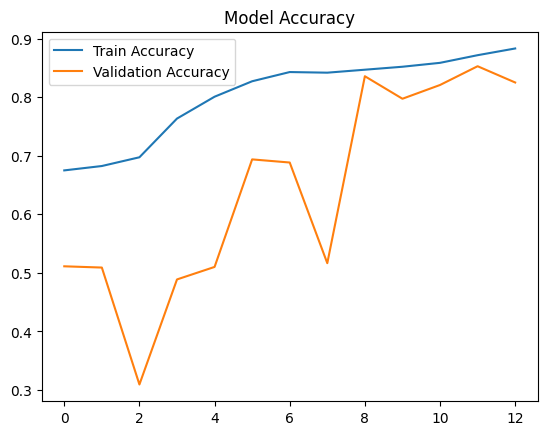

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.title('Model Accuracy')
plt.show()